# Step 1: V1 Match Analysis

Compare V1 prediction results across experimental conditions from the retina–BBScore integration and foundation model baselines.

## Experimental Conditions & Preprocessing

All models are evaluated on the **TVSDV1** benchmark (natural images). The table below summarizes the stimuli and preprocessing applied by each model wrapper:

| Model | Stimulus Type | Preprocessing Steps | Model Input Shape (per sample) |
| :--- | :--- | :--- | :--- |
| **grayscale_pixel** | Grayscale | convert("L"), resize (80, 160), scale [0, 1]. **No** ImageNet normalization. | `(1, 1, 80, 160)` (1 frame, 1 channel) |
| **retina_ln** | Grayscale (Temporal) | convert("L"), resize (80, 160), scale [0, 1], subtract mean. Replicated to **50 frames** (steady-state). | `(1, 50, 80, 160)` (50 frames, 1 channel) |
| **retina_cnn** | Grayscale (Temporal) | Same as `retina_ln`. | `(1, 50, 80, 160)` (50 frames, 1 channel) |
| **dinov2_base** | Color (RGB) | convert("RGB"), resize (256), center crop (224), **ImageNet normalization**. | `(3, 224, 224)` (3 channels, RGB) |
| **dinov2_base_grayscale** | Grayscale (Control) | convert("L"), **replicate to 3 channels**, resize (256), center crop (224), ImageNet normalization. | `(3, 224, 224)` (3 channels, Gray-as-RGB) |

**Notation:**
- **B (Batch):** Number of images in a batch (handled by the extractor).
- **T (Temporal):** Number of frames in the input window. For static images, the retina model uses $T=50$ identical frames to simulate steady-state response.
- **C (Channels):** Number of color or luminance channels (1 for grayscale, 3 for RGB).

## Commands to generate features

From the project root (`bbscore_cs375_project_2026/`), run:

**Pixel Baseline and Retina Layers:**
```bash
python run.py --model pixel --layer identity_layer --benchmark TVSDV1 --metric ridge --save-features && \
python run.py --model grayscale_pixel --layer identity_layer --benchmark TVSDV1 --metric ridge --save-features && \
python run.py --model retina_cnn --layer conv0 --benchmark TVSDV1 --metric ridge --save-features && \
python run.py --model retina_cnn --layer conv1 --benchmark TVSDV1 --metric ridge --save-features && \
```

**DINOv2:**  
*Note: DINOv2 uses `torch.compile`, so layer names require the `_orig_mod` prefix.*
```bash
python run.py --model dinov2_base --layer _orig_mod.encoder.layer.0 --benchmark TVSDV1 --metric ridge --save-features && \
python run.py --model dinov2_base --layer _orig_mod.encoder.layer.2 --benchmark TVSDV1 --metric ridge --save-features && \
python run.py --model dinov2_base --layer _orig_mod.encoder.layer.5 --benchmark TVSDV1 --metric ridge --save-features && \
python run.py --model dinov2_base --layer _orig_mod.encoder.layer.11 --benchmark TVSDV1 --metric ridge --save-features
```

**DINOv2 Grayscale Control:**
```bash
python run.py --model dinov2_base_grayscale --layer _orig_mod.encoder.layer.0 --benchmark TVSDV1 --metric ridge --save-features && \
python run.py --model dinov2_base_grayscale --layer _orig_mod.encoder.layer.2 --benchmark TVSDV1 --metric ridge --save-features && \
python run.py --model dinov2_base_grayscale --layer _orig_mod.encoder.layer.5 --benchmark TVSDV1 --metric ridge --save-features && \
python run.py --model dinov2_base_grayscale --layer _orig_mod.encoder.layer.11 --benchmark TVSDV1 --metric ridge --save-features
```

**DINOv2 Pre-Transformer Embeddings:**
```bash
python run.py --model dinov2_base --layer _orig_mod.embeddings --benchmark TVSDV1 --metric ridge --save-features && \
python run.py --model dinov2_base_grayscale --layer _orig_mod.embeddings --benchmark TVSDV1 --metric ridge --save-features && \
```

Results are saved to `bbscore_data/results/`.

In [29]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Per-voxel metric key order (used for best-match selection; violin uses raw_pearson directly)
METRIC_KEYS = ("median_ceiled_pearson", "ceiled_pearson", "median_unceiled_pearson", "raw_pearson")
METRIC_LABEL = "Per-voxel Pearson r (unceiled)"

# Paths
RESULTS_DIR = "/Volumes/Lab/Users/xzhou25/bbscore_cs375_project_2026/bbscore_data/results"
FEATURES_DIR = "/Volumes/Lab/Users/xzhou25/bbscore_cs375_project_2026/bbscore_data/features"

# TVSDV1 ridge + RSA
FILES_TVSDV1 = {
    "grayscale_pixel (Cond. A)": "grayscale_pixel_identity_layer_TVSDV1.pkl",
    "PIXEL_identity_layer": "pixel_identity_layer_TVSDV1.pkl",
    "retina_ln (Cond. B)": "retina_ln_linear_TVSDV1.pkl",
    "retina_cnn_conv0 (Cond. C)": "retina_cnn_conv0_TVSDV1.pkl",
    "retina_cnn_conv1 (Cond. C)": "retina_cnn_conv1_TVSDV1.pkl",
    "retina_cnn_linear (Cond. C)": "retina_cnn_linear_TVSDV1.pkl",
    "dinov2_gray_layer0": "dinov2_base_grayscale__orig_mod.encoder.layer.0_TVSDV1.pkl",
    "dinov2_gray_layer2": "dinov2_base_grayscale__orig_mod.encoder.layer.2_TVSDV1.pkl",
    "dinov2_gray_layer5": "dinov2_base_grayscale__orig_mod.encoder.layer.5_TVSDV1.pkl",
    "dinov2_gray_layer11": "dinov2_base_grayscale__orig_mod.encoder.layer.11_TVSDV1.pkl",
    "dinov2_layer0": "dinov2_base__orig_mod.encoder.layer.0_TVSDV1.pkl",
    "dinov2_layer2": "dinov2_base__orig_mod.encoder.layer.2_TVSDV1.pkl",
    "dinov2_layer5": "dinov2_base__orig_mod.encoder.layer.5_TVSDV1.pkl",
    "dinov2_layer11": "dinov2_base__orig_mod.encoder.layer.11_TVSDV1.pkl",
    "dinov2_embed": "dinov2_base__orig_mod.embeddings_TVSDV1.pkl",
    "dinov2_patch_embed": "dinov2_base__orig_mod.embeddings.patch_embeddings_TVSDV1.pkl",
    "dinov2_gray_embed": "dinov2_base_grayscale__orig_mod.embeddings_TVSDV1.pkl",
    "dinov2_gray_patch_embed": "dinov2_base_grayscale__orig_mod.embeddings.patch_embeddings_TVSDV1.pkl",
}

# Per-monkey ridge (best layers only)
FILES_MONKEY_F = {
    "grayscale_pixel": "grayscale_pixel_identity_layer_TVSDMonkeyFV1.pkl",
    "retina_cnn_conv1": "retina_cnn_conv1_TVSDMonkeyFV1.pkl",
    "dinov2_layer2": "dinov2_base__orig_mod.encoder.layer.2_TVSDMonkeyFV1.pkl",
    "dinov2_gray_layer2": "dinov2_base_grayscale__orig_mod.encoder.layer.2_TVSDMonkeyFV1.pkl",
}
FILES_MONKEY_N = {
    "grayscale_pixel": "grayscale_pixel_identity_layer_TVSDMonkeyNV1.pkl",
    "retina_cnn_conv1": "retina_cnn_conv1_TVSDMonkeyNV1.pkl",
    "dinov2_layer2": "dinov2_base__orig_mod.encoder.layer.2_TVSDMonkeyNV1.pkl",
    "dinov2_gray_layer2": "dinov2_base_grayscale__orig_mod.encoder.layer.2_TVSDMonkeyNV1.pkl",
}

def _extract_ridge_and_rsa(metrics):
    """From metrics (dict or list of dicts), extract ridge and rsa_scores."""
    ridge, rsa = None, None
    entries = [metrics] if isinstance(metrics, dict) else metrics
    for m in entries:
        if not isinstance(m, dict):
            continue
        if ridge is None:
            ridge = m.get("ridge") or m.get("torch_ridge")
        if "rsa" in m and rsa is None and isinstance(m.get("rsa"), dict):
            rsa = m["rsa"].get("rsa_scores")
        if "rsa_scores" in m and rsa is None:
            rsa = m["rsa_scores"]
    return ridge, rsa

def load_results():
    """Load TVSDV1 results; prefer ridge when metrics list has both ridge and RSA."""
    out = {}
    rsa_out = {}
    for label, fname in FILES_TVSDV1.items():
        path = os.path.join(RESULTS_DIR, fname)
        if not os.path.exists(path):
            print(f"Missing: {path}")
            continue
        with open(path, "rb") as f:
            data = pickle.load(f)
        metrics = data.get("metrics")
        if metrics is None:
            continue
        ridge, rsa = _extract_ridge_and_rsa(metrics)
        if ridge is not None:
            out[label] = {"ridge": ridge}
            ceil = data.get("ceiling")
            if ceil is not None:
                out[label]["ceiling"] = np.asarray(ceil)
        if rsa is not None:
            rsa_out[label] = rsa
    return out, rsa_out

def load_per_monkey_results():
    """Load per-monkey ridge results."""
    monkey_f, monkey_n = {}, {}
    for label, fname in FILES_MONKEY_F.items():
        path = os.path.join(RESULTS_DIR, fname)
        if os.path.exists(path):
            with open(path, "rb") as f:
                data = pickle.load(f)
            metrics = data.get("metrics")
            if metrics is not None:
                ridge, _ = _extract_ridge_and_rsa(metrics)
                if ridge is not None:
                    monkey_f[label] = ridge
    for label, fname in FILES_MONKEY_N.items():
        path = os.path.join(RESULTS_DIR, fname)
        if os.path.exists(path):
            with open(path, "rb") as f:
                data = pickle.load(f)
            metrics = data.get("metrics")
            if metrics is not None:
                ridge, _ = _extract_ridge_and_rsa(metrics)
                if ridge is not None:
                    monkey_n[label] = ridge
    return monkey_f, monkey_n

results, rsa_results = load_results()
monkey_f_results, monkey_n_results = load_per_monkey_results()
print(f"Loaded {len(results)} TVSDV1 conditions, RSA: {len(rsa_results)}, MonkeyF: {len(monkey_f_results)}, MonkeyN: {len(monkey_n_results)}")

Loaded 18 TVSDV1 conditions, RSA: 4, MonkeyF: 4, MonkeyN: 4


In [30]:
# Print ridge results for each condition
SUMMARY_KEYS = [
    "final_pearson", "final_unceiled_pearson",
    "final_r2", "final_unceiled_r2",
]

for label in results:
    ridge = results[label].get("ridge") if isinstance(results[label], dict) else results[label]
    if not isinstance(ridge, dict):
        ridge = {}
    print(f"\n{'='*60}\n{label}\n{'='*60}")
    for k in SUMMARY_KEYS:
        if k in ridge:
            v = ridge[k]
            if np.isscalar(v):
                print(f"  {k}: {v:.6f}")
            elif hasattr(v, "flat"):
                print(f"  {k}: {float(np.asarray(v).flat[0]):.6f}")
            else:
                print(f"  {k}: (array shape {np.shape(v)})")


grayscale_pixel (Cond. A)
  final_pearson: 0.498060
  final_unceiled_pearson: 0.459215
  final_r2: 0.077598
  final_unceiled_r2: 0.074591

PIXEL_identity_layer
  final_pearson: 0.578826
  final_unceiled_pearson: 0.519758
  final_r2: 0.105063
  final_unceiled_r2: 0.101065

retina_ln (Cond. B)
  final_pearson: 0.402073
  final_unceiled_pearson: 0.366528
  final_r2: 0.037921
  final_unceiled_r2: 0.034143

retina_cnn_conv0 (Cond. C)
  final_pearson: 0.441110
  final_unceiled_pearson: 0.398723
  final_r2: 0.049782
  final_unceiled_r2: 0.046663

retina_cnn_conv1 (Cond. C)
  final_pearson: 0.709007
  final_unceiled_pearson: 0.665875
  final_r2: 0.243143
  final_unceiled_r2: 0.234085

retina_cnn_linear (Cond. C)
  final_pearson: 0.408151
  final_unceiled_pearson: 0.353995
  final_r2: 0.035422
  final_unceiled_r2: 0.031666

dinov2_gray_layer0
  final_pearson: 0.923416
  final_unceiled_pearson: 0.879575
  final_r2: 0.624888
  final_unceiled_r2: 0.603096

dinov2_gray_layer2
  final_pearson: 0.93

In [31]:
# Extract summary metrics and build comparison table
SUMMARY_KEYS = [
    "final_pearson", "final_unceiled_pearson",
    "final_r2", "final_unceiled_r2",
]
# Spatial mean vs final: with a single train/test split, median_ceiled_* has length 1,
# so nanmedian(median_*) == final_* — identical bars. Compare spatial mean to final instead.
SPATIAL_MEAN_COLUMNS = [
    ("spatial_mean_ceiled_pearson", "ceiled_pearson"),
    ("spatial_mean_unceiled_pearson", "raw_pearson"),
    ("spatial_mean_ceiled_r2", "ceiled_r2"),
    ("spatial_mean_unceiled_r2", "raw_r2"),
]


def _spatial_mean_summary(ridge, array_key):
    """Mean over folds of (mean over voxels per fold); contrasts with final_* (mean of spatial medians)."""
    if array_key not in ridge:
        return np.nan
    a = np.asarray(ridge[array_key], dtype=float)
    if a.ndim == 0:
        return float(a)
    if a.ndim == 1:
        return float(np.nanmean(a))
    return float(np.nanmean(np.nanmean(a, axis=1)))


summary = {}
for label, metrics in results.items():
    ridge = metrics.get("ridge") if isinstance(metrics, dict) else None
    if ridge is None:
        continue
    row = {k: float(ridge[k]) for k in SUMMARY_KEYS if k in ridge}
    for col_name, rk in SPATIAL_MEAN_COLUMNS:
        if rk in ridge:
            row[col_name] = _spatial_mean_summary(ridge, rk)
    summary[label] = row

# Comparison table
df = pd.DataFrame(summary).T
df = df.round(6)
print("Summary metrics (higher = better):")
display(df)

# Best model per metric (final_* only)
print("\nBest model/layer per metric:")
for col in SUMMARY_KEYS:
    if col not in df.columns:
        continue
    best = df[col].idxmax()
    print(f"  {col}: {best} ({df.loc[best, col]:.6f})")

# Best layer per model (for cross-model comparison)
BEST_LAYER_LABELS_TARGET = [
    "grayscale_pixel (Cond. A)",
    "retina_cnn_conv1 (Cond. C)",
    "dinov2_embed",
    "dinov2_gray_embed",
    "dinov2_layer2",
    "dinov2_gray_layer2",
]
available_best = [l for l in BEST_LAYER_LABELS_TARGET if l in df.index]
df_best = df.loc[available_best, :] if available_best else pd.DataFrame()
BEST_LAYER_LABELS = list(df_best.index) if len(df_best) > 0 else []
print("\nBest layer per model (for visualization):")
display(df_best)

Summary metrics (higher = better):


,final_pearson,final_unceiled_pearson,final_r2,final_unceiled_r2,spatial_mean_ceiled_pearson,spatial_mean_unceiled_pearson,spatial_mean_ceiled_r2,spatial_mean_unceiled_r2
grayscale_pixel (Cond. A),0.498060,0.459215,0.077598,0.074591,-526.106816,0.428398,-3364.326965,0.101622
PIXEL_identity_layer,0.578826,0.519758,0.105063,0.101065,-323.717531,0.486816,-9199.514884,0.115446
retina_ln (Cond. B),0.402073,0.366528,0.037921,0.034143,-581.194282,0.314917,-1482.938642,0.044799
retina_cnn_conv0 (Cond. C),0.441110,0.398723,0.049782,0.046663,-482.408529,0.367972,-3195.520027,0.067021
retina_cnn_conv1 (Cond. C),0.709007,0.665875,0.243143,0.234085,-221.451630,0.602723,-9431.422585,0.200217
retina_cnn_linear (Cond. C),0.408151,0.353995,0.035422,0.031666,649.707845,0.338105,-1204.578901,0.040090
dinov2_gray_layer0,0.923416,0.879575,0.624888,0.603096,-1074.972634,0.789465,-46602.449996,0.359022
dinov2_gray_layer2,0.939763,0.897696,0.676163,0.653304,668.997784,0.811105,-18192.433459,0.513538
dinov2_gray_layer5,0.897822,0.854561,0.560771,0.539743,491.837861,0.774768,-8171.623682,0.464773
dinov2_gray_layer11,0.781740,0.740218,0.342246,0.328016,460.763362,0.668668,-37383.031010,0.163580



Best model/layer per metric:
  final_pearson: dinov2_layer2 (0.949934)
  final_unceiled_pearson: dinov2_layer2 (0.913628)
  final_r2: dinov2_layer2 (0.716581)
  final_unceiled_r2: dinov2_layer2 (0.690235)

Best layer per model (for visualization):


,final_pearson,final_unceiled_pearson,final_r2,final_unceiled_r2,spatial_mean_ceiled_pearson,spatial_mean_unceiled_pearson,spatial_mean_ceiled_r2,spatial_mean_unceiled_r2
grayscale_pixel (Cond. A),0.498060,0.459215,0.077598,0.074591,-526.106816,0.428398,-3364.326965,0.101622
retina_cnn_conv1 (Cond. C),0.709007,0.665875,0.243143,0.234085,-221.451630,0.602723,-9431.422585,0.200217
dinov2_embed,0.538408,0.478655,0.078995,0.076952,-1097.038627,0.451104,-17173.016832,0.057029
dinov2_gray_embed,0.451875,0.404942,0.045309,0.042402,-1269.419246,0.387852,-15886.618049,0.019798
dinov2_layer2,0.949934,0.913628,0.716581,0.690235,625.587635,0.827097,-18541.151629,0.547040
dinov2_gray_layer2,0.939763,0.897696,0.676163,0.653304,668.997784,0.811105,-18192.433459,0.513538


Per-voxel best-match (which model best predicts each V1 channel):
  dinov2_layer2: best for 492 voxels (48.0%)
  dinov2_gray_layer2: best for 221 voxels (21.6%)
  dinov2_layer0: best for 174 voxels (17.0%)
  dinov2_gray_layer0: best for 42 voxels (4.1%)
  dinov2_gray_layer5: best for 36 voxels (3.5%)
  retina_cnn_linear (Cond. C): best for 11 voxels (1.1%)
  PIXEL_identity_layer: best for 7 voxels (0.7%)
  dinov2_layer11: best for 7 voxels (0.7%)
  dinov2_gray_layer11: best for 7 voxels (0.7%)
  dinov2_layer5: best for 6 voxels (0.6%)
  retina_ln (Cond. B): best for 6 voxels (0.6%)
  retina_cnn_conv1 (Cond. C): best for 5 voxels (0.5%)
  dinov2_patch_embed: best for 5 voxels (0.5%)
  dinov2_gray_embed: best for 2 voxels (0.2%)
  grayscale_pixel (Cond. A): best for 2 voxels (0.2%)
  retina_cnn_conv0 (Cond. C): best for 1 voxels (0.1%)
Saved figure (300 dpi): /Volumes/Lab/Users/xzhou25/bbscore_cs375_project_2026/project/report/figures/per_voxel_match_to_v1.png


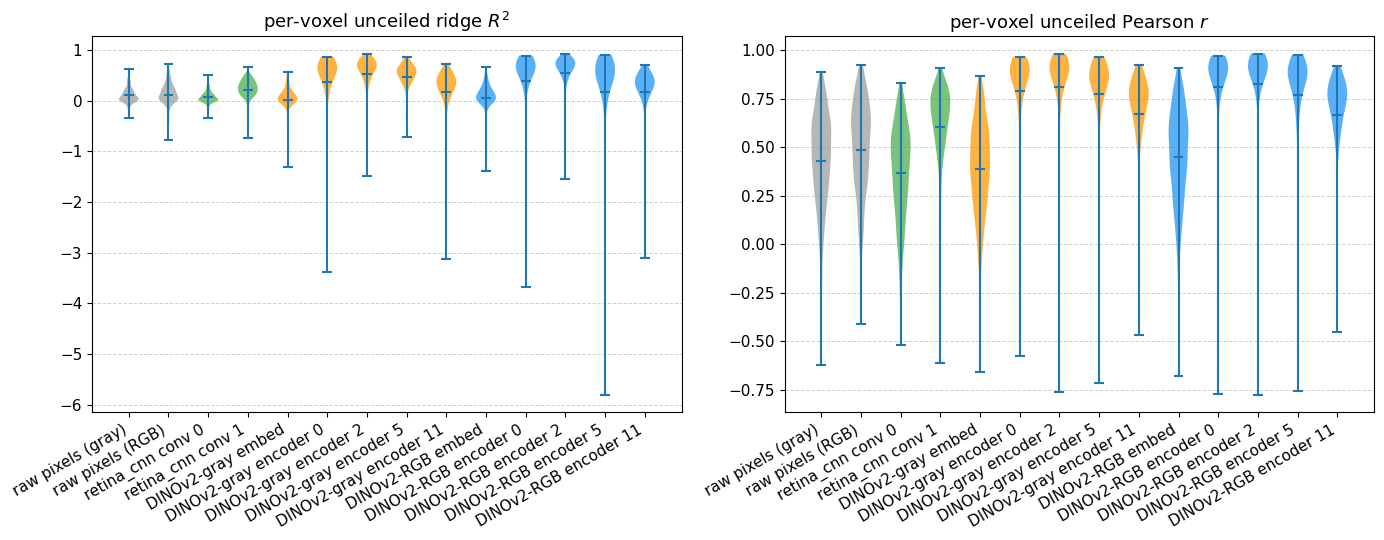

In [32]:
# ========== AGGREGATE BLOCK: per-voxel analysis (TVSDV1 combined) ==========
# Raw R² and raw Pearson r violins; y-axis auto-scaled to the full data range.

import os

def _to_per_voxel_array(arr):
    """1D per-voxel array; (n_folds, n_voxels) → mean over folds; object K-fold ok."""
    a = np.asarray(arr)
    if a.size == 1 and a.dtype == object:
        a = np.asarray(a.flat[0])
    if a.dtype == object and a.ndim == 1:
        a = np.stack([np.asarray(x, dtype=np.float64).reshape(-1) for x in a], axis=0)
    if a.ndim == 2:
        a = np.nanmean(a, axis=0)
    a = np.asarray(a, dtype=np.float64).flatten()
    return a if len(a) > 1 else None


def _get_per_voxel_from_ridge(ridge_dict, key):
    arr = ridge_dict.get(key)
    if arr is not None and hasattr(arr, "shape"):
        return _to_per_voxel_array(arr)
    return None


def _get_per_voxel_pearson_from_ridge(ridge_dict):
    return _get_per_voxel_from_ridge(ridge_dict, "raw_pearson")


conditions_with_per_voxel = []
for name, metrics in results.items():
    r = metrics.get("ridge") if isinstance(metrics, dict) else None
    if r is None:
        continue
    mp = _get_per_voxel_pearson_from_ridge(r)
    if mp is not None:
        conditions_with_per_voxel.append((name, mp))

if conditions_with_per_voxel:
    n_voxels = conditions_with_per_voxel[0][1].shape[0]
    scores = np.stack([mp for _, mp in conditions_with_per_voxel])
    names = [n for n, _ in conditions_with_per_voxel]
    best_idx = np.argmax(scores, axis=0)

    from collections import Counter
    counts = Counter(best_idx)
    print("Per-voxel best-match (which model best predicts each V1 channel):")
    for idx, cnt in sorted(counts.items(), key=lambda x: -x[1]):
        pct = 100 * cnt / n_voxels
        print(f"  {names[idx]}: best for {cnt} voxels ({pct:.1f}%)")

    VIOLIN_INCLUDE = {
        "grayscale_pixel (Cond. A)": "pixel",
        "PIXEL_identity_layer": "pixel",
        "retina_cnn_conv0 (Cond. C)": "retina_cnn",
        "retina_cnn_conv1 (Cond. C)": "retina_cnn",
        "dinov2_gray_embed": "dinov2_gray",
        "dinov2_gray_layer0": "dinov2_gray",
        "dinov2_gray_layer2": "dinov2_gray",
        "dinov2_gray_layer5": "dinov2_gray",
        "dinov2_gray_layer11": "dinov2_gray",
        "dinov2_embed": "dinov2_rgb",
        "dinov2_layer0": "dinov2_rgb",
        "dinov2_layer2": "dinov2_rgb",
        "dinov2_layer5": "dinov2_rgb",
        "dinov2_layer11": "dinov2_rgb",
    }
    GROUP_COLORS = {
        "pixel":       "#9E9E9E",
        "dinov2_rgb":  "#2196F3",
        "dinov2_gray": "#FF9800",
        "retina_cnn":  "#4CAF50",
    }
    DISPLAY_NAMES = {
        "grayscale_pixel (Cond. A)": "raw pixels (gray)",
        "PIXEL_identity_layer": "raw pixels (RGB)",
        "retina_cnn_conv0 (Cond. C)": "retina_cnn conv 0",
        "retina_cnn_conv1 (Cond. C)": "retina_cnn conv 1",
        "dinov2_gray_layer0":  "DINOv2-gray encoder 0",
        "dinov2_gray_layer2":  "DINOv2-gray encoder 2",
        "dinov2_gray_layer5":  "DINOv2-gray encoder 5",
        "dinov2_gray_layer11": "DINOv2-gray encoder 11",
        "dinov2_layer0":  "DINOv2-RGB encoder 0",
        "dinov2_layer2":  "DINOv2-RGB encoder 2",
        "dinov2_layer5":  "DINOv2-RGB encoder 5",
        "dinov2_layer11": "DINOv2-RGB encoder 11",
        "dinov2_embed": "DINOv2-RGB embed",
        "dinov2_gray_embed": "DINOv2-gray embed",
    }
    MODEL_ORDER = [
        "grayscale_pixel (Cond. A)",
        "PIXEL_identity_layer",
        "retina_cnn_conv0 (Cond. C)", "retina_cnn_conv1 (Cond. C)",
        "dinov2_gray_embed",
        "dinov2_gray_layer0", "dinov2_gray_layer2", "dinov2_gray_layer5", "dinov2_gray_layer11",
        "dinov2_embed",
        "dinov2_layer0", "dinov2_layer2", "dinov2_layer5", "dinov2_layer11",
    ]

    filtered_names = [
        n for n, _ in conditions_with_per_voxel
        if n in VIOLIN_INCLUDE
    ]
    filtered_names = sorted(
        filtered_names,
        key=lambda x: MODEL_ORDER.index(x) if x in MODEL_ORDER else 999,
    )

    if filtered_names:
        violin_labels = [DISPLAY_NAMES.get(n, n) for n in filtered_names]
        violin_colors = [GROUP_COLORS[VIOLIN_INCLUDE[n]] for n in filtered_names]

        # Original wide aspect (14×5.5); fonts scaled up for print/report readability
        _fig_w, _fig_h = 14, 5.5
        _fs_xtick, _fs_ytick = 11, 11
        _fs_panel = 13
        _fs_suptitle = 14

        def _violin_on_ax(ax, data_list, title):
            # np.arange: avoids failure if builtin `range` was shadowed (e.g. range = [0, 100]).
            parts = ax.violinplot(
                data_list, positions=np.arange(len(data_list)),
                showmeans=True, showmedians=False,
            )
            for pc, color in zip(parts["bodies"], violin_colors):
                pc.set_facecolor(color)
                pc.set_alpha(0.75)
            ax.set_xticks(np.arange(len(filtered_names)))
            ax.set_xticklabels(
                violin_labels, rotation=30, ha="right", fontsize=_fs_xtick,
            )
            ax.tick_params(axis="y", labelsize=_fs_ytick)
            ax.set_title(title, fontsize=_fs_panel)
            ax.set_axisbelow(True)
            ax.grid(
                axis="y",
                which="major",
                linestyle="--",
                linewidth=0.7,
                alpha=0.45,
                color="0.6",
                zorder=0,
            )
            # full y-range from data (no fixed ylim)

        panels = [
            ("raw_r2", r"per-voxel unceiled ridge $R^2$"),
            ("raw_pearson", r"per-voxel unceiled Pearson $r$"),
        ]

        fig, axes = plt.subplots(1, 2, figsize=(_fig_w, _fig_h), sharex=True)
        for ax, (mkey, title_short) in zip(axes, panels):
            row = []
            for n in filtered_names:
                r = results[n]["ridge"]
                v = _get_per_voxel_from_ridge(r, mkey)
                if v is None or v.shape[0] != n_voxels:
                    row = None
                    break
                row.append(v)
            if row is None:
                ax.set_visible(False)
                continue
            _violin_on_ax(ax, row, title_short)
        # fig.suptitle(
        #     "Per-voxel V1 match by model layer",
        #     fontsize=_fs_suptitle,
        #     y=1.02,
        # )
        plt.tight_layout()
        _repo_root = os.path.dirname(os.path.dirname(RESULTS_DIR))
        _report_dir = os.path.join(_repo_root, "project", "report", "figures")
        os.makedirs(_report_dir, exist_ok=True)
        _violin_png = os.path.join(_report_dir, "per_voxel_match_to_v1.png")
        fig.savefig(
            _violin_png,
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
        )
        print(f"Saved figure (300 dpi): {_violin_png}")
        plt.show()
    else:
        print("No matching conditions found for violin plot.")
        
else:
    print("Per-voxel scores not available (aggregate). Run ridge on TVSDV1.")

Saved figure (300 dpi): /Volumes/Lab/Users/xzhou25/bbscore_cs375_project_2026/project/report/figures/overall_match_to_v1.png


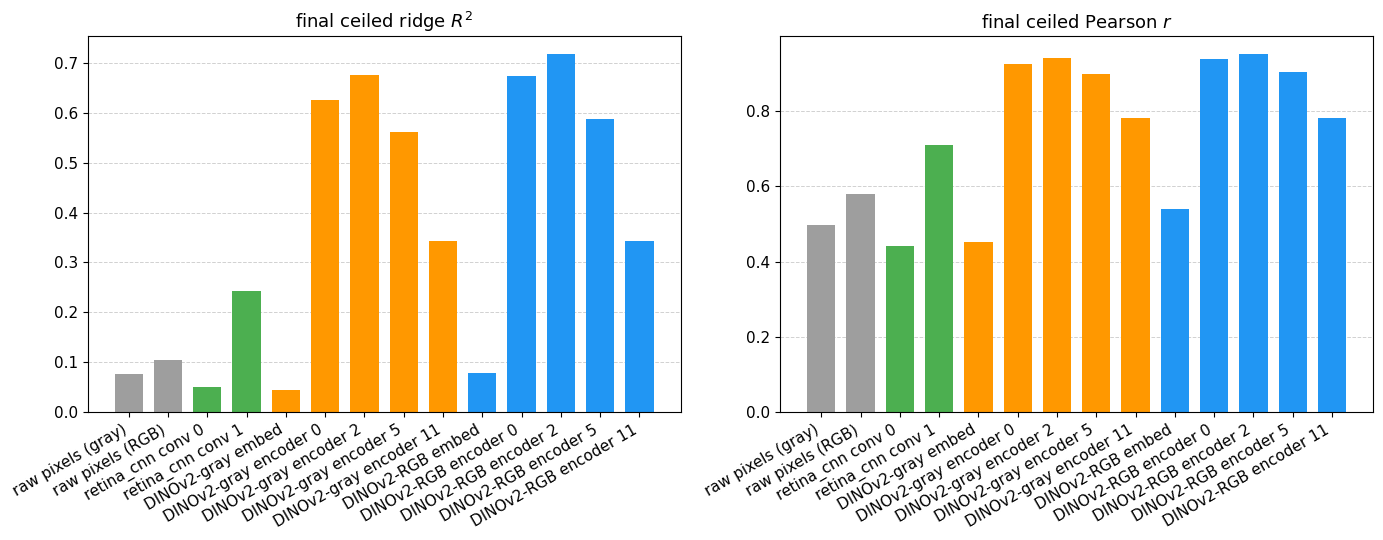

In [33]:
# Visualization: 1×2 bar charts — ridge `final_*` summaries (ceiled), same layers as per-voxel violins.
#
# How `final_r2` / `final_pearson` are computed (metrics/ridge.py → RidgeMetric.compute):
#   1) Per voxel on the held-out set: raw Pearson r or R² between predictions and neural response.
#   2) Ceiled per voxel: raw / that voxel's noise ceiling (elementwise).
#   3) If scores are 2D (n_eval × n_voxels): take median along axis 1 (median across voxels for each eval row).
#   4) final_* = mean across eval rows (K-fold folds, or a single train/test row on TVSDV1).
# On TVSDV1 the benchmark passes train + test features, so there is one eval row: step (3) is the median
# across V1 voxels of ceiled scores; step (4) is trivial. Ceiled ratios need not lie in [0, 1].
import os

VIOLIN_INCLUDE = {
    "grayscale_pixel (Cond. A)": "pixel",
    "PIXEL_identity_layer": "pixel",
    "retina_cnn_conv0 (Cond. C)": "retina_cnn",
    "retina_cnn_conv1 (Cond. C)": "retina_cnn",
    "dinov2_gray_embed": "dinov2_gray",
    "dinov2_gray_layer0": "dinov2_gray",
    "dinov2_gray_layer2": "dinov2_gray",
    "dinov2_gray_layer5": "dinov2_gray",
    "dinov2_gray_layer11": "dinov2_gray",
    "dinov2_embed": "dinov2_rgb",
    "dinov2_layer0": "dinov2_rgb",
    "dinov2_layer2": "dinov2_rgb",
    "dinov2_layer5": "dinov2_rgb",
    "dinov2_layer11": "dinov2_rgb",
}
BAR_DISPLAY_NAMES = {
    "grayscale_pixel (Cond. A)": "raw pixels (gray)",
    "PIXEL_identity_layer": "raw pixels (RGB)",
    "retina_cnn_conv0 (Cond. C)": "retina_cnn conv 0",
    "retina_cnn_conv1 (Cond. C)": "retina_cnn conv 1",
    "dinov2_gray_layer0":  "DINOv2-gray encoder 0",
    "dinov2_gray_layer2":  "DINOv2-gray encoder 2",
    "dinov2_gray_layer5":  "DINOv2-gray encoder 5",
    "dinov2_gray_layer11": "DINOv2-gray encoder 11",
    "dinov2_layer0":  "DINOv2-RGB encoder 0",
    "dinov2_layer2":  "DINOv2-RGB encoder 2",
    "dinov2_layer5":  "DINOv2-RGB encoder 5",
    "dinov2_layer11": "DINOv2-RGB encoder 11",
    "dinov2_embed": "DINOv2-RGB embed",
    "dinov2_gray_embed": "DINOv2-gray embed",
}
GROUP_COLORS = {
    "pixel":       "#9E9E9E",
    "dinov2_rgb":  "#2196F3",
    "dinov2_gray": "#FF9800",
    "retina_cnn":  "#4CAF50",
}
MODEL_ORDER = [
    "grayscale_pixel (Cond. A)",
    "PIXEL_identity_layer",
    "retina_cnn_conv0 (Cond. C)", "retina_cnn_conv1 (Cond. C)",
    "dinov2_gray_embed",
    "dinov2_gray_layer0", "dinov2_gray_layer2", "dinov2_gray_layer5", "dinov2_gray_layer11",
    "dinov2_embed",
    "dinov2_layer0", "dinov2_layer2", "dinov2_layer5", "dinov2_layer11",
]
# Match per-voxel violin figure size and fonts (aggregate block).
_fig_w, _fig_h = 14, 5.5
_fs_xtick, _fs_ytick = 11, 11
_fs_panel = 13

FINAL_PANELS = [
    ("final_r2", r"final ceiled ridge $R^2$"),
    ("final_pearson", r"final ceiled Pearson $r$"),
]

plot_df = df
if len(plot_df) > 0:
    labels = [l for l in MODEL_ORDER if l in plot_df.index]
    plot_df = plot_df.loc[labels] if labels else plot_df

if len(plot_df) > 0:
    display_labels = [BAR_DISPLAY_NAMES.get(l, l) for l in plot_df.index]
    bar_colors = [GROUP_COLORS[VIOLIN_INCLUDE[l]] for l in plot_df.index]
    n = len(plot_df)
    x = np.arange(n)
    # Bar width in data coords (tick spacing = 1); ~0.72 fills most of each slot.
    w = 0.72
    fig, axes = plt.subplots(1, 2, figsize=(_fig_w, _fig_h), sharex=True)
    for ax, (col, title) in zip(np.ravel(axes), FINAL_PANELS):
        if col not in plot_df.columns:
            ax.set_visible(False)
            continue
        vals = plot_df[col].values.astype(float)
        ax.bar(x, vals, width=w, color=bar_colors)
        ax.set_title(title, fontsize=_fs_panel)
        ax.set_xticks(x)
        ax.set_xticklabels(
            display_labels, rotation=30, ha="right", fontsize=_fs_xtick,
        )
        ax.tick_params(axis="y", labelsize=_fs_ytick)
        ax.set_axisbelow(True)
        ax.grid(
            axis="y",
            which="major",
            linestyle="--",
            linewidth=0.7,
            alpha=0.45,
            color="0.6",
            zorder=0,
        )
        ax.axhline(0, color="0.5", lw=0.5, zorder=2)
    # fig.suptitle("Overall V1 match by model layer (best layer per model)", y=1.02)
    plt.tight_layout()
    _repo_root = os.path.dirname(os.path.dirname(RESULTS_DIR))
    _report_dir = os.path.join(_repo_root, "project", "report", "figures")
    os.makedirs(_report_dir, exist_ok=True)
    _bar_png = os.path.join(_report_dir, "overall_match_to_v1.png")
    fig.savefig(
        _bar_png,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )
    print(f"Saved figure (300 dpi): {_bar_png}")
    plt.show()
else:
    print("No summary data to plot.")

Saved figure (300 dpi): /Volumes/Lab/Users/xzhou25/bbscore_cs375_project_2026/project/report/figures/per_voxel_unique_var.png


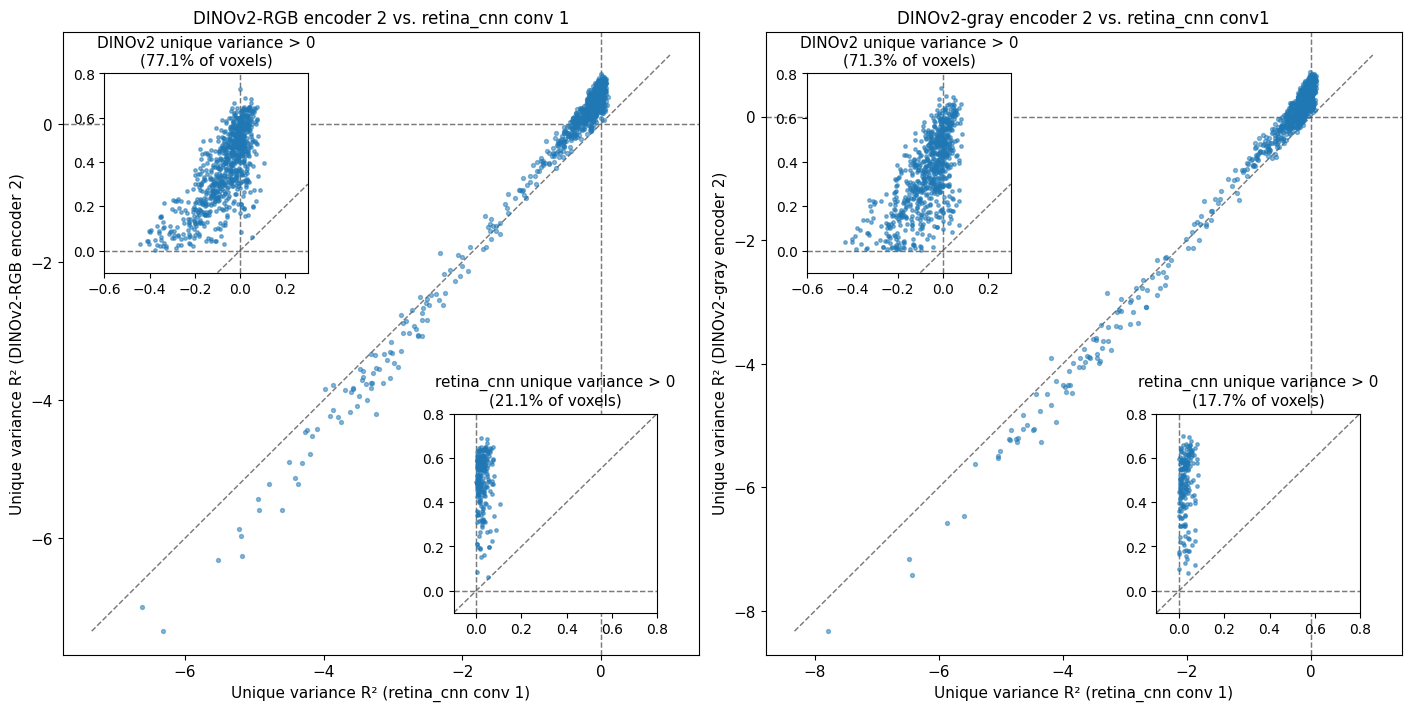

--- DINOv2-RGB block 2 vs retina_cnn conv 1 ---
Mean unique retina R²: -0.4432
Mean unique DINOv2 R²: -0.0964
Mean shared R²: 0.6435
Mean joint R²: 0.1038
Voxels with unique DINOv2-RGB block 2 > unique retina_cnn conv 1: 91.7%
--- DINOv2-gray block 2 vs retina_cnn conv 1 ---
Mean unique retina R²: -0.4940
Mean unique DINOv2-gray R²: -0.1807
Mean shared R²: 0.6942
Mean joint R²: 0.0195
Voxels with unique DINOv2-gray block 2 > unique retina_cnn conv 1: 91.1%


In [34]:
# Variance Partitioning: unique variance explained by retina vs. DINOv2
# Raw additive R² differences (not floored): unique_retina = joint - dino, unique_dino = joint - retina.
# These can be negative when joint R² is not comparable to singles (e.g. joint < single-model R²).
# Joint R² from run_variance_partitioning.py:
#   RGB:  Joint_retina_cnn_dinov2_base_TVSDV1.pkl
#   Gray: Joint_retina_cnn_dinov2_base_grayscale_TVSDV1.pkl

def _load_joint_r2(path, run_hint):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Joint pickle not found: {path}\nRun: {run_hint}")
    with open(path, "rb") as f:
        return np.asarray(pickle.load(f)["r2_per_voxel"]).flatten()

joint_pkl_rgb = os.path.join(RESULTS_DIR, "Joint_retina_cnn_dinov2_base_TVSDV1.pkl")
joint_pkl_gray = os.path.join(RESULTS_DIR, "Joint_retina_cnn_dinov2_base_grayscale_TVSDV1.pkl")
_HINT_RGB = (
    "python run_variance_partitioning.py --model-a retina_cnn --layer-a conv1 "
    "--model-b dinov2_base --layer-b _orig_mod.encoder.layer.2"
)
_HINT_GRAY = (
    "python run_variance_partitioning.py --model-a retina_cnn --layer-a conv1 "
    "--model-b dinov2_base_grayscale --layer-b _orig_mod.encoder.layer.2"
)
joint_rgb_v = _load_joint_r2(joint_pkl_rgb, _HINT_RGB)
joint_gray_v = _load_joint_r2(joint_pkl_gray, _HINT_GRAY)

# Per-voxel R² from single models (from saved TVSDV1 results)
def _get_r2(ridge_dict):
    for key in ("raw_r2", "r2"):
        arr = ridge_dict.get(key)
        if arr is not None:
            return arr
    return None

retina_r2 = _get_r2(results.get("retina_cnn_conv1 (Cond. C)", {}).get("ridge", {}))
dino_rgb_r2 = _get_r2(results.get("dinov2_layer2", {}).get("ridge", {}))
dino_gray_r2 = _get_r2(results.get("dinov2_gray_layer2", {}).get("ridge", {}))

def to_per_voxel(arr):
    """Extract per-voxel 1D array; handles object wrap, (n_folds,n_voxels) K-fold case."""
    a = np.asarray(arr)
    if a.size == 1 and a.dtype == object:
        a = np.asarray(a.flat[0])
    if a.ndim == 2:
        # K-fold: (n_folds, n_voxels) -> take mean over folds
        a = np.nanmean(a, axis=0)
    return np.asarray(a).flatten() if np.size(a) > 1 else np.atleast_1d(a)

retina_r2_v = to_per_voxel(retina_r2) if retina_r2 is not None else None
dino_rgb_v = to_per_voxel(dino_rgb_r2) if dino_rgb_r2 is not None else None
dino_gray_v = to_per_voxel(dino_gray_r2) if dino_gray_r2 is not None else None

if retina_r2_v is not None and dino_rgb_v is not None and dino_gray_v is not None:
    n_v = min(
        len(joint_rgb_v),
        len(joint_gray_v),
        len(retina_r2_v),
        len(dino_rgb_v),
        len(dino_gray_v),
    )
    if n_v == 0:
        print("No voxels overlap for variance partitioning.")
    else:
        j_rgb, j_gray = joint_rgb_v[:n_v], joint_gray_v[:n_v]
        rv = retina_r2_v[:n_v]
        dv_rgb, dv_gray = dino_rgb_v[:n_v], dino_gray_v[:n_v]
        unique_retina_rgb = j_rgb - dv_rgb
        unique_dino_rgb = j_rgb - rv
        unique_retina_gray = j_gray - dv_gray
        unique_dino_gray = j_gray - rv
        shared_rgb = np.clip(rv + dv_rgb - j_rgb, 0, None)
        shared_gray = np.clip(rv + dv_gray - j_gray, 0, None)
        pct_unique_dino_gt_retina_rgb = 100.0 * float(np.mean(unique_dino_rgb > unique_retina_rgb))
        pct_unique_dino_gt_retina_gray = 100.0 * float(np.mean(unique_dino_gray > unique_retina_gray))

        from matplotlib.ticker import MultipleLocator
        from mpl_toolkits.axes_grid1.inset_locator import inset_axes

        # x=0, y=0, and y=x share one style (similar weight; points drawn on top).
        _ref_kw = dict(linestyle="--", linewidth=1.05, alpha=0.72, color="0.28", zorder=2)
        _fs_xtick, _fs_ytick = 11, 11
        _fs_inset = 10
        _inset_tick_step = 0.2
        _fig_w = 14.0
        _fig_h = _fig_w / 2.0
        _inset_wh = "32%"
        _inset_pad = 3
        _inset_ylim = (-0.1, 0.8)
        _inset_xlim_topleft = (-0.6, 0.3)
        _inset_xlim_bottomright = (-0.1, 0.8)

        def _add_halfplane_insets(ax, ux, uy, *, n_total, ref_kw, fs_ins, tick_step):
            """Upper-left: y>0; lower-right: x>0. Fixed limits; full frame; matched tick step."""
            ux = np.asarray(ux, dtype=float)
            uy = np.asarray(uy, dtype=float)

            def _pct(mask):
                return 100.0 * float(np.sum(mask)) / float(n_total) if n_total else 0.0

            def _apply_inset_ticks(a):
                loc = MultipleLocator(tick_step)
                a.xaxis.set_major_locator(loc)
                a.yaxis.set_major_locator(loc)

            def _full_frame(a):
                for s in a.spines.values():
                    s.set_visible(True)

            def _y_eq_x_segment(axes_inset, xlim, ylim):
                x0, x1 = xlim
                y0, y1 = ylim
                lo = max(x0, y0)
                hi = min(x1, y1)
                if lo < hi:
                    axes_inset.plot([lo, hi], [lo, hi], **ref_kw)

            # y > 0 — DINO unique variance (top-left inset)
            my = uy > 0
            pct_y = _pct(my)
            ins_y = inset_axes(
                ax, width=_inset_wh, height=_inset_wh, loc="upper left", borderpad=_inset_pad
            )
            ins_y.set_axisbelow(True)
            if np.any(my):
                ins_y.scatter(ux[my], uy[my], alpha=0.55, s=6, zorder=3)
            ins_y.set_xlim(*_inset_xlim_topleft)
            ins_y.set_ylim(*_inset_ylim)
            ins_y.axhline(0, **ref_kw)
            ins_y.axvline(0, **ref_kw)
            _y_eq_x_segment(ins_y, _inset_xlim_topleft, _inset_ylim)
            _apply_inset_ticks(ins_y)
            _tlx0, _tlx1 = _inset_xlim_topleft
            # 0.2 spacing; same tick positions as before (-0.6 … 0.2); xlim extends to _tlx1
            _xt_ins = np.arange(_tlx0, _tlx1 + tick_step, tick_step)
            ins_y.set_xticks(_xt_ins[_xt_ins <= _tlx1 + 1e-9])
            _full_frame(ins_y)
            ins_y.tick_params(axis="both", labelsize=fs_ins)
            ins_y.set_title(
                f"DINOv2 unique variance > 0\n({pct_y:.1f}% of voxels)",
                fontsize=fs_ins + 1,
            )

            # x > 0 — retina unique variance (bottom-right inset)
            mx = ux > 0
            pct_x = _pct(mx)
            ins_x = inset_axes(
                ax, width=_inset_wh, height=_inset_wh, loc="lower right", borderpad=_inset_pad
            )
            ins_x.set_axisbelow(True)
            if np.any(mx):
                ins_x.scatter(ux[mx], uy[mx], alpha=0.55, s=6, zorder=3)
            ins_x.set_xlim(*_inset_xlim_bottomright)
            ins_x.set_ylim(*_inset_ylim)
            ins_x.axhline(0, **ref_kw)
            ins_x.axvline(0, **ref_kw)
            _y_eq_x_segment(ins_x, _inset_xlim_bottomright, _inset_ylim)
            _apply_inset_ticks(ins_x)
            _full_frame(ins_x)
            ins_x.tick_params(axis="both", labelsize=fs_ins)
            ins_x.set_title(
                f"retina_cnn unique variance > 0\n({pct_x:.1f}% of voxels)",
                fontsize=fs_ins + 1,
            )

        def _scatter_unique(ax, ux, uy, *, ylabel, n_total, ref_kw, fs_ins):
            ax.set_axisbelow(True)
            ax.scatter(ux, uy, alpha=0.5, s=8, zorder=3)
            ax.axhline(0, **ref_kw)
            ax.axvline(0, **ref_kw)
            ax.set_xlabel("Unique variance R² (retina_cnn conv 1)", fontsize=_fs_xtick)
            ax.set_ylabel(ylabel, fontsize=_fs_xtick)
            ax.tick_params(axis="both", labelsize=_fs_ytick)
            umin = np.nanmin([np.nanmin(ux), np.nanmin(uy)])
            umax = np.nanmax([np.nanmax(ux), np.nanmax(uy)])
            lo, hi = min(umin, 0), max(umax, 1)
            ax.plot([lo, hi], [lo, hi], **ref_kw)
            ax.set_aspect("equal", adjustable="datalim")
            _add_halfplane_insets(
                ax,
                ux,
                uy,
                n_total=n_total,
                ref_kw=ref_kw,
                fs_ins=fs_ins,
                tick_step=_inset_tick_step,
            )

        fig, axes = plt.subplots(1, 2, figsize=(_fig_w, _fig_h), constrained_layout=True)
        _scatter_unique(
            axes[0],
            unique_retina_rgb,
            unique_dino_rgb,
            ylabel="Unique variance R² (DINOv2-RGB encoder 2)",
            n_total=n_v,
            ref_kw=_ref_kw,
            fs_ins=_fs_inset,
        )
        _scatter_unique(
            axes[1],
            unique_retina_gray,
            unique_dino_gray,
            ylabel="Unique variance R² (DINOv2-gray encoder 2)",
            n_total=n_v,
            ref_kw=_ref_kw,
            fs_ins=_fs_inset,
        )
        axes[0].set_title(
            "DINOv2-RGB encoder 2 vs. retina_cnn conv 1",
            fontsize=_fs_xtick + 1,
        )
        axes[1].set_title(
            "DINOv2-gray encoder 2 vs. retina_cnn conv1",
            fontsize=_fs_xtick + 1,
        )

        _repo_root = os.path.dirname(os.path.dirname(RESULTS_DIR))
        _report_dir = os.path.join(_repo_root, "project", "report", "figures")
        os.makedirs(_report_dir, exist_ok=True)
        _unique_png = os.path.join(_report_dir, "per_voxel_unique_var.png")
        fig.savefig(
            _unique_png,
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
        )
        print(f"Saved figure (300 dpi): {_unique_png}")
        plt.show()

        print("--- DINOv2-RGB block 2 vs retina_cnn conv 1 ---")
        print(f"Mean unique retina R²: {unique_retina_rgb.mean():.4f}")
        print(f"Mean unique DINOv2 R²: {unique_dino_rgb.mean():.4f}")
        print(f"Mean shared R²: {shared_rgb.mean():.4f}")
        print(f"Mean joint R²: {j_rgb.mean():.4f}")
        print(
            f"Voxels with unique DINOv2-RGB block 2 > unique retina_cnn conv 1: "
            f"{pct_unique_dino_gt_retina_rgb:.1f}%"
        )
        print("--- DINOv2-gray block 2 vs retina_cnn conv 1 ---")
        print(f"Mean unique retina R²: {unique_retina_gray.mean():.4f}")
        print(f"Mean unique DINOv2-gray R²: {unique_dino_gray.mean():.4f}")
        print(f"Mean shared R²: {shared_gray.mean():.4f}")
        print(f"Mean joint R²: {j_gray.mean():.4f}")
        print(
            f"Voxels with unique DINOv2-gray block 2 > unique retina_cnn conv 1: "
            f"{pct_unique_dino_gt_retina_gray:.1f}%"
        )
else:
    print(
        "Missing single-model raw_r2 for variance partitioning. "
        "Ensure retina_cnn_conv1, dinov2_layer2, and dinov2_gray_layer2 ridge results include raw_r2."
    )